# Week 2, Step 8: Pair Feature Exploratory Data Analysis

This notebook inspects the labeled aircraft-pair features from Steps 6 and 7. It checks data quality, class imbalance, feature distributions, correlations, feature relationships, and outliers, then saves report artifacts under `experiments/`.

The current input is one OpenSky snapshot. It validates the pipeline, but cannot support temporal training or evaluation.

Dataset: c:\Users\bandish1304\Desktop\Airspace collision prevention\data\processed\states_socal_1787874146_pairs_labeled.csv
Shape: 8,309 rows x 24 columns
Columns: ['snapshot_time', 'icao24_a', 'icao24_b', 'position_age_a_s', 'position_age_b_s', 'latitude_a', 'longitude_a', 'altitude_a_m', 'velocity_a_mps', 'true_track_a_deg', 'latitude_b', 'longitude_b', 'altitude_b_m', 'velocity_b_mps', 'true_track_b_deg', 'lateral_distance_m', 'lateral_distance_nm', 'closing_speed_mps', 'bearing_difference_deg', 'vertical_separation_m', 'time_to_cpa_s', 'collision_risk', 'lateral_separation_limit_nm', 'vertical_separation_limit_ft']


,snapshot_time,icao24_a,icao24_b,position_age_a_s,position_age_b_s,latitude_a,longitude_a,altitude_a_m,velocity_a_mps,true_track_a_deg,latitude_b,longitude_b,altitude_b_m,velocity_b_mps,true_track_b_deg,lateral_distance_m,lateral_distance_nm,closing_speed_mps,bearing_difference_deg,vertical_separation_m,time_to_cpa_s,collision_risk,lateral_separation_limit_nm,vertical_separation_limit_ft
0,1787874146,a22233,a9656c,0,0,33.812,-118.320,396.240,52.520,122.600,34.169,-118.533,426.720,53.530,289.650,44373.954,23.960,-83.325,167.050,30.480,inf,0,5.000,1000.000
1,1787874146,a22233,a9c84f,0,1,33.812,-118.320,396.240,52.520,122.600,33.884,-118.223,320.040,41.830,4.940,12079.356,6.522,-16.566,117.660,76.200,inf,0,5.000,1000.000
2,1787874146,a22233,a4d984,0,0,33.812,-118.320,396.240,52.520,122.600,34.116,-118.871,579.120,40.040,117.550,61028.644,32.953,-12.707,5.050,182.880,inf,0,5.000,1000.000
3,1787874146,a22233,a8a93a,0,0,33.812,-118.320,396.240,52.520,122.600,33.808,-118.297,1615.440,54.230,136.920,2207.777,1.192,5.036,14.320,1219.200,61.801,0,5.000,1000.000
4,1787874146,a22233,ac247a,0,0,33.812,-118.320,396.240,52.520,122.600,33.571,-118.763,3893.820,175.210,107.960,48911.967,26.410,88.582,14.640,3497.580,276.843,0,5.000,1000.000


Data quality checks:


,count
self_pairs,0
duplicate_unordered_pairs,0
negative_lateral_distance,0
negative_vertical_separation,0
bearing_outside_0_to_180,0
negative_finite_tcpa,0
infinite_tcpa,4091


,missing_values,missing_percent
snapshot_time,0,0.000
icao24_a,0,0.000
icao24_b,0,0.000
position_age_a_s,0,0.000
position_age_b_s,0,0.000
latitude_a,0,0.000
longitude_a,0,0.000
altitude_a_m,0,0.000
velocity_a_mps,0,0.000
true_track_a_deg,0,0.000


,count,mean,std,min,25%,50%,75%,max
lateral_distance_nm,8309.000,28.929,12.713,0.376,18.906,29.549,39.856,49.990
vertical_separation_m,8309.000,2750.741,2680.531,0.000,609.600,1767.840,4335.780,12847.320
closing_speed_mps,8309.000,1.138,132.975,-494.355,-79.643,1.590,83.018,470.604
bearing_difference_deg,8309.000,89.569,55.637,0.000,38.360,91.110,140.830,179.950
time_to_cpa_s,4218.000,448.623,1325.855,0.053,112.213,242.502,450.131,43248.930


,count,percent
collision_risk,,
Not risk,8254,99.338
Risk,55,0.662


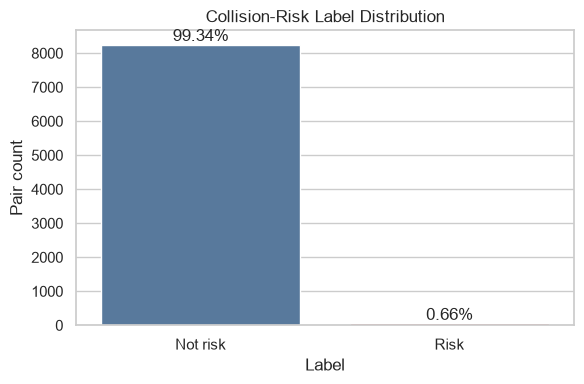

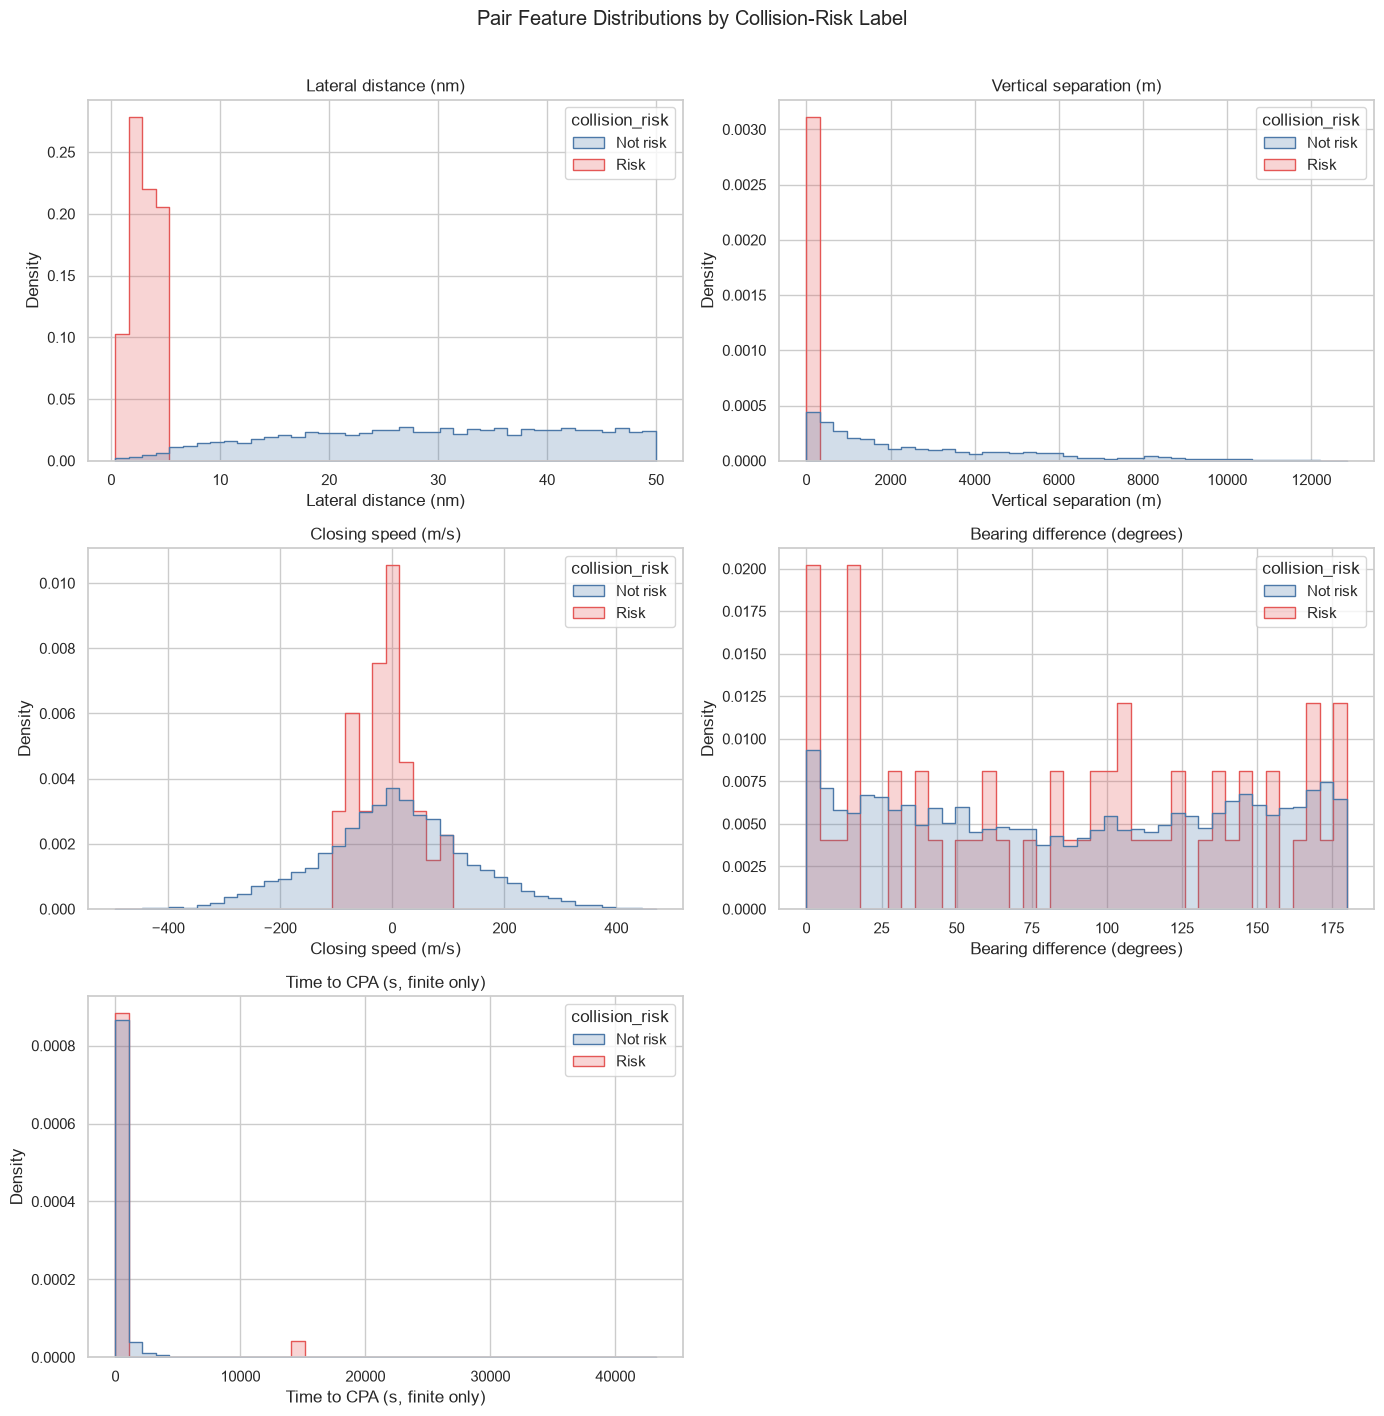

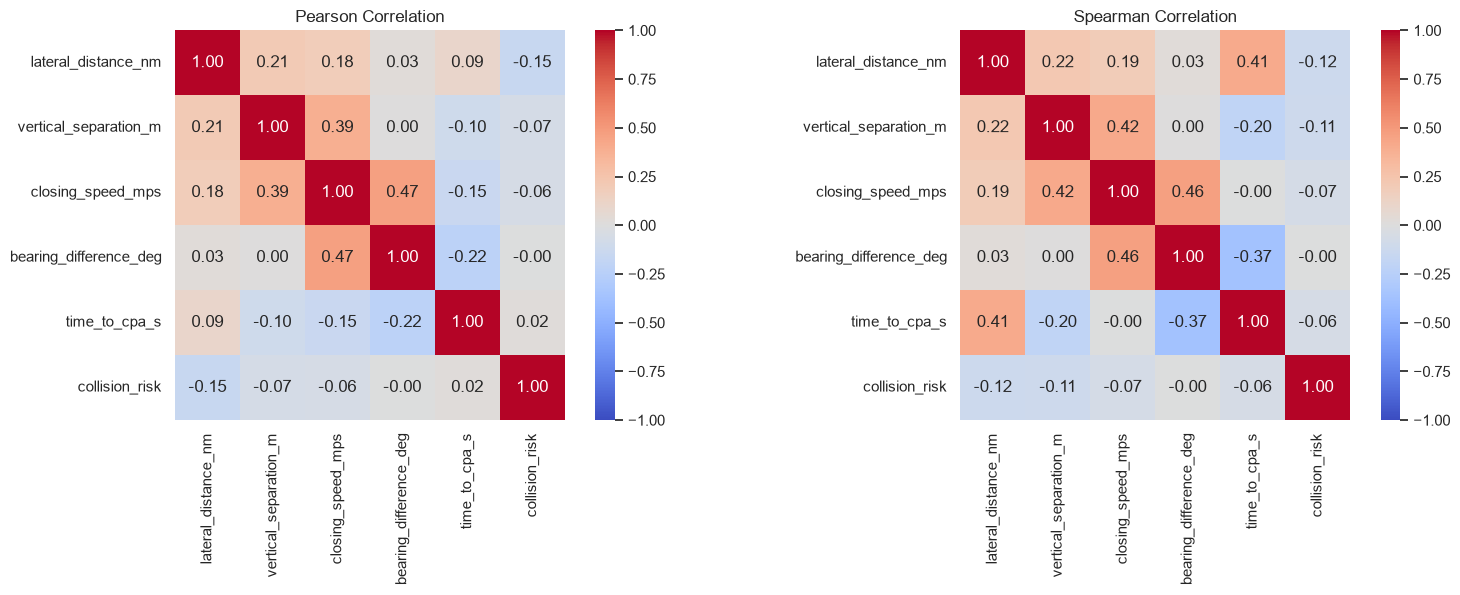

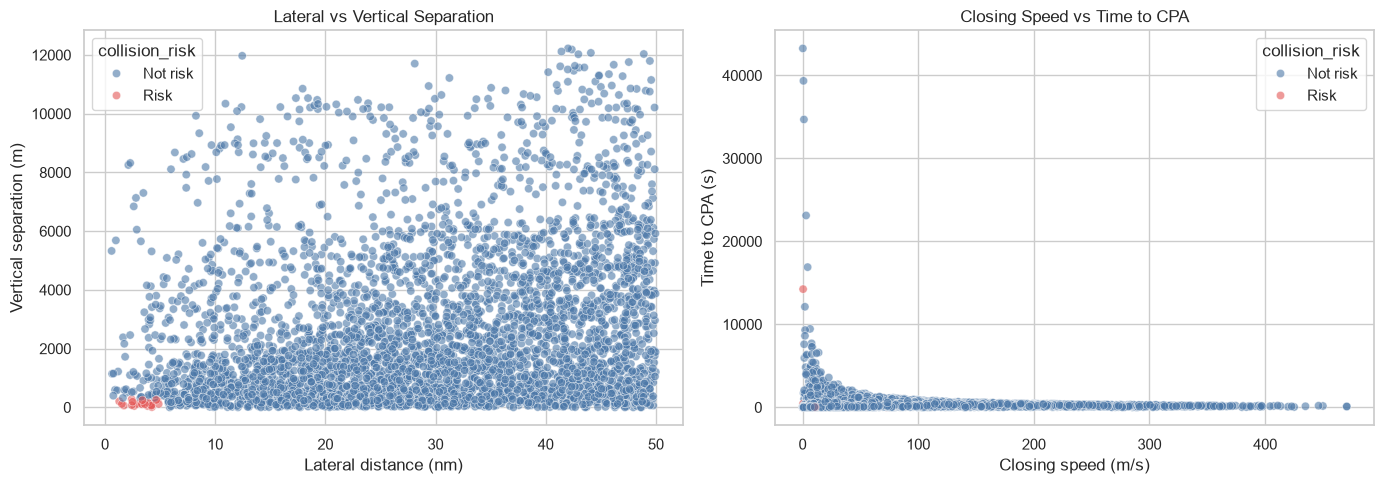

,iqr_outlier_count
lateral_distance_nm,0
vertical_separation_m,184
closing_speed_mps,139
bearing_difference_deg,0
time_to_cpa_s,346


Label sanity check passed: all labelable rows match the configured separation rule.
Risk examples:


,icao24_a,icao24_b,lateral_distance_nm,vertical_separation_m,closing_speed_mps,bearing_difference_deg,time_to_cpa_s,collision_risk
31,a22233,a06cf3,3.361,121.920,51.195,144.950,33.304,1
76,a22233,a6ef00,2.227,15.240,-77.534,178.380,inf,1
88,a22233,ad47e4,4.755,251.460,86.721,175.420,94.500,1
190,a9656c,a5ba10,2.947,152.400,-42.634,66.030,inf,1
210,a9656c,a2036b,3.867,45.720,97.898,163.430,69.578,1


Not-risk examples:


,icao24_a,icao24_b,lateral_distance_nm,vertical_separation_m,closing_speed_mps,bearing_difference_deg,time_to_cpa_s,collision_risk
0,a22233,a9656c,23.960,30.480,-83.325,167.050,inf,0
1,a22233,a9c84f,6.522,76.200,-16.566,117.660,inf,0
2,a22233,a4d984,32.953,182.880,-12.707,5.050,inf,0
3,a22233,a8a93a,1.192,1219.200,5.036,14.320,61.801,0
4,a22233,ac247a,26.410,3497.580,88.582,14.640,276.843,0


Saved figures to: c:\Users\bandish1304\Desktop\Airspace collision prevention\experiments\figures
Saved tables to: c:\Users\bandish1304\Desktop\Airspace collision prevention\experiments\eda


In [2]:
# Week 2, step 8: load the labeled pair dataset and prepare artifact folders.
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "states_socal_1787874146_pairs_labeled.csv"
FIGURES_DIR = PROJECT_ROOT / "experiments" / "figures"
TABLES_DIR = PROJECT_ROOT / "experiments" / "eda"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:.3f}".format)
sns.set_theme(style="whitegrid", context="notebook")

pairs = pd.read_csv(DATA_PATH)
feature_columns = [
    "lateral_distance_nm",
    "vertical_separation_m",
    "closing_speed_mps",
    "bearing_difference_deg",
    "time_to_cpa_s",
]

print(f"Dataset: {DATA_PATH}")
print(f"Shape: {pairs.shape[0]:,} rows x {pairs.shape[1]} columns")
print("Columns:", pairs.columns.tolist())
display(pairs.head())

# Week 2, step 8: validate basic data quality and save numerical summaries.
canonical_pairs = pairs[["icao24_a", "icao24_b"]].apply(
    lambda pair: tuple(sorted((pair.iloc[0], pair.iloc[1]))), axis=1
)
finite_tcpa = pairs["time_to_cpa_s"].replace([np.inf, -np.inf], np.nan)
quality_summary = pd.DataFrame(
    {"missing_values": pairs.isna().sum(), "missing_percent": pairs.isna().mean().mul(100)}
).sort_values("missing_values", ascending=False)
range_checks = pd.Series(
    {
        "self_pairs": int((pairs["icao24_a"] == pairs["icao24_b"]).sum()),
        "duplicate_unordered_pairs": int(canonical_pairs.duplicated().sum()),
        "negative_lateral_distance": int((pairs["lateral_distance_nm"] < 0).sum()),
        "negative_vertical_separation": int((pairs["vertical_separation_m"] < 0).sum()),
        "bearing_outside_0_to_180": int(((pairs["bearing_difference_deg"] < 0) | (pairs["bearing_difference_deg"] > 180)).sum()),
        "negative_finite_tcpa": int((finite_tcpa < 0).sum()),
        "infinite_tcpa": int(np.isinf(pairs["time_to_cpa_s"]).sum()),
    },
    name="count",
)
feature_summary = pairs[feature_columns].replace([np.inf, -np.inf], np.nan).describe().T
quality_summary.to_csv(TABLES_DIR / "pair_feature_missing_values.csv")
range_checks.to_csv(TABLES_DIR / "pair_feature_range_checks.csv")
feature_summary.to_csv(TABLES_DIR / "pair_feature_summary.csv")
print("Data quality checks:")
display(range_checks.to_frame())
display(quality_summary)
display(feature_summary)

# Week 2, step 8: calculate, plot, and export collision-risk class balance.
label_counts = pairs["collision_risk"].value_counts(dropna=False).sort_index()
label_summary = pd.DataFrame({"count": label_counts, "percent": label_counts.div(len(pairs)).mul(100)})
label_summary.index = label_summary.index.map({0: "Not risk", 1: "Risk"}).fillna("Unlabelled")
label_summary.to_csv(TABLES_DIR / "collision_risk_class_distribution.csv")
display(label_summary)
fig, axis = plt.subplots(figsize=(6, 4))
sns.barplot(x=label_summary.index, y=label_summary["count"], hue=label_summary.index, palette={"Not risk": "#4C78A8", "Risk": "#E45756", "Unlabelled": "#9D9D9D"}, legend=False, ax=axis)
axis.set(title="Collision-Risk Label Distribution", xlabel="Label", ylabel="Pair count")
for index, row in label_summary.reset_index().iterrows():
    axis.text(index, row["count"], f"{row['percent']:.2f}%", ha="center", va="bottom")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "collision_risk_class_distribution.png", dpi=160)
plt.show()

# Week 2, step 8: compare the engineered feature distributions by label.
plot_data = pairs.dropna(subset=["collision_risk"]).copy()
plot_data["collision_risk"] = plot_data["collision_risk"].map({0: "Not risk", 1: "Risk"})
plot_features = [
    ("lateral_distance_nm", "Lateral distance (nm)"),
    ("vertical_separation_m", "Vertical separation (m)"),
    ("closing_speed_mps", "Closing speed (m/s)"),
    ("bearing_difference_deg", "Bearing difference (degrees)"),
    ("time_to_cpa_s", "Time to CPA (s, finite only)"),
]
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
for axis, (column, label) in zip(axes.flat, plot_features):
    values = plot_data[[column, "collision_risk"]].replace([np.inf, -np.inf], np.nan).dropna()
    sns.histplot(data=values, x=column, hue="collision_risk", bins=40, stat="density", common_norm=False, element="step", palette={"Not risk": "#4C78A8", "Risk": "#E45756"}, ax=axis)
    axis.set(title=label, xlabel=label, ylabel="Density")
axes.flat[-1].set_visible(False)
fig.suptitle("Pair Feature Distributions by Collision-Risk Label", y=1.01)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "pair_feature_distributions_by_label.png", dpi=160, bbox_inches="tight")
plt.show()

# Week 2, step 8: calculate and plot feature correlations.
correlation_columns = [*feature_columns, "collision_risk"]
correlation_data = pairs[correlation_columns].replace([np.inf, -np.inf], np.nan).dropna()
pearson_correlation = correlation_data.corr(method="pearson")
spearman_correlation = correlation_data.corr(method="spearman")
pearson_correlation.to_csv(TABLES_DIR / "pair_feature_pearson_correlation.csv")
spearman_correlation.to_csv(TABLES_DIR / "pair_feature_spearman_correlation.csv")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for axis, correlation, method in zip(axes, [pearson_correlation, spearman_correlation], ["Pearson", "Spearman"]):
    sns.heatmap(correlation, vmin=-1, vmax=1, center=0, cmap="coolwarm", annot=True, fmt=".2f", square=True, ax=axis)
    axis.set_title(f"{method} Correlation")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "pair_feature_correlations.png", dpi=160, bbox_inches="tight")
plt.show()

# Week 2, step 8: inspect relationships and count IQR outliers without modifying data.
finite_plot_data = plot_data.replace([np.inf, -np.inf], np.nan).dropna(subset=["lateral_distance_nm", "vertical_separation_m", "time_to_cpa_s"])
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=finite_plot_data, x="lateral_distance_nm", y="vertical_separation_m", hue="collision_risk", palette={"Not risk": "#4C78A8", "Risk": "#E45756"}, alpha=0.6, ax=axes[0])
axes[0].set(title="Lateral vs Vertical Separation", xlabel="Lateral distance (nm)", ylabel="Vertical separation (m)")
sns.scatterplot(data=finite_plot_data, x="closing_speed_mps", y="time_to_cpa_s", hue="collision_risk", palette={"Not risk": "#4C78A8", "Risk": "#E45756"}, alpha=0.6, ax=axes[1])
axes[1].set(title="Closing Speed vs Time to CPA", xlabel="Closing speed (m/s)", ylabel="Time to CPA (s)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "pair_feature_relationships.png", dpi=160, bbox_inches="tight")
plt.show()

outlier_counts = {}
for column in feature_columns:
    values = pairs[column].replace([np.inf, -np.inf], np.nan).dropna()
    lower_quartile, upper_quartile = values.quantile([0.25, 0.75])
    interquartile_range = upper_quartile - lower_quartile
    outlier_counts[column] = int(((values < lower_quartile - 1.5 * interquartile_range) | (values > upper_quartile + 1.5 * interquartile_range)).sum())
outlier_summary = pd.Series(outlier_counts, name="iqr_outlier_count").to_frame()
outlier_summary.to_csv(TABLES_DIR / "pair_feature_iqr_outliers.csv")
display(outlier_summary)

# Week 2, step 8: verify the labels and inspect representative records.
vertical_limit_m = pairs["vertical_separation_limit_ft"] * 0.3048
expected_risk = (pairs["lateral_distance_nm"] <= pairs["lateral_separation_limit_nm"]) & (pairs["vertical_separation_m"] <= vertical_limit_m)
labelable = pairs["lateral_distance_nm"].notna() & pairs["vertical_separation_m"].notna()
actual_risk = pairs["collision_risk"].astype("Int64")
assert actual_risk.loc[labelable].eq(expected_risk.loc[labelable].astype("Int64")).all()
print("Label sanity check passed: all labelable rows match the configured separation rule.")
example_columns = ["icao24_a", "icao24_b", "lateral_distance_nm", "vertical_separation_m", "closing_speed_mps", "bearing_difference_deg", "time_to_cpa_s", "collision_risk"]
print("Risk examples:")
display(pairs.loc[actual_risk == 1, example_columns].head(5))
print("Not-risk examples:")
display(pairs.loc[actual_risk == 0, example_columns].head(5))
print(f"Saved figures to: {FIGURES_DIR}")
print(f"Saved tables to: {TABLES_DIR}")

## Interpretation Notes

- This single snapshot is appropriate for validating pair construction, feature calculations, and the EDA workflow. It cannot support temporal training, chronological splits, or meaningful model evaluation.
- `lateral_distance_nm` and `vertical_separation_m` directly define `collision_risk` in the current rule. Their correlation with the target is label leakage by construction, not independent predictive evidence.
- Before Week 3 modeling, collect historical trajectory data and define a prediction horizon so features at time $t$ predict a risk state at a later time.